# Cat and Dog Image Classification Using Deep Learning  
## Comparative Study of SimpleCNN, MobileNetV2, ResNet50, and Ensemble Averaging

**Student Project Report Notebook**

---

## 1. Project Introduction

This project focuses on building an Artificial Intelligence system for **cat and dog image classification**.  
The main objective is not only to train a model, but also to **compare multiple deep learning models** and determine which model is most suitable for practical use.

In this project, four approaches are considered:

1. **SimpleCNN** — a baseline model built from scratch  
2. **MobileNetV2** — a lightweight pretrained deep learning model  
3. **ResNet50** — a deeper pretrained model with stronger feature extraction capability  
4. **EnsembleAvg** — a combined prediction approach using the average output of the three trained models  

The final goal is to:
- compare model performance,
- identify the best-performing approach,
- and prepare the selected model for real-world usage in an AI classification system.


## 2. Project Objectives

The objectives of this project are:

- To build an AI model that can classify images into **cats** and **dogs**
- To compare the performance of multiple deep learning models
- To evaluate the models using standard metrics:
  - Accuracy
  - Precision
  - Recall
  - F1-score
- To investigate whether **ensemble learning** improves the final result
- To prepare the best model for deployment and practical use


## 3. Dataset Description

The dataset used in this project contains images from two classes:

- **Cats**
- **Dogs**

The dataset was divided into three subsets:

- **Training set:** 70%
- **Validation set:** 15%
- **Test set:** 15%

This split allows the project to:
- train the models on the training set,
- monitor performance on the validation set,
- and report final results using the unseen test set.


## 3.1 Data Exploration and Visualization

Before training the models, it is important to explore the dataset structure and visualize representative samples.
This helps us understand class distribution, image diversity, and possible data issues before model development.

The purposes of this step are:
- to check whether the classes are balanced,
- to inspect the visual characteristics of cat and dog images,
- and to gain an initial understanding of the classification problem.


In [ ]:
import os
import random
from PIL import Image
import matplotlib.pyplot as plt

train_cat_path = "dataset/train/cats"
train_dog_path = "dataset/train/dogs"

num_cats = len(os.listdir(train_cat_path))
num_dogs = len(os.listdir(train_dog_path))

print("Number of cat images in training set:", num_cats)
print("Number of dog images in training set:", num_dogs)

plt.figure(figsize=(6,4))
plt.bar(["Cats", "Dogs"], [num_cats, num_dogs])
plt.title("Class Distribution in Training Set")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.show()


In [ ]:
def show_samples(folder, label, n=3):
    image_names = random.sample(os.listdir(folder), n)
    plt.figure(figsize=(10,3))
    for i, img_name in enumerate(image_names):
        img = Image.open(os.path.join(folder, img_name)).convert("RGB")
        plt.subplot(1, n, i + 1)
        plt.imshow(img)
        plt.title(label)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_samples(train_cat_path, "Cat")
show_samples(train_dog_path, "Dog")


### 3.2 Data Exploration Insight

From the data exploration step, we can observe that:
- the dataset contains two clearly defined classes: cats and dogs,
- the training data is sufficiently large for deep learning experiments,
- and the images show variation in pose, background, and lighting conditions.

These variations increase the difficulty of the task, but also make the project more realistic and suitable for evaluating the robustness of different deep learning models.


## 4. Data Preparation

Before training the models, the data must be prepared in a format suitable for machine learning algorithms.

The preparation process in this project includes:
1. organizing images into `train`, `val`, and `test` folders,
2. separating the two classes into `cats` and `dogs`,
3. resizing the images to **224 × 224** pixels,
4. applying preprocessing compatible with pretrained models,
5. and using a consistent input format for all models.

The dataset split used in this project is:
- **Training set:** 70%
- **Validation set:** 15%
- **Test set:** 15%

This preparation ensures that:
- the models are trained on one subset,
- tuned or monitored on another,
- and finally evaluated on unseen data for fair comparison.


## 5. Model Selection and Fine-Tuning Strategy

This project compares three single-model approaches and one ensemble approach.

### 5.1 SimpleCNN
SimpleCNN is a baseline convolutional neural network built from scratch.
It is included to provide a reference point for comparing pretrained models.

### 5.2 MobileNetV2
MobileNetV2 is a pretrained deep learning model originally trained on ImageNet.
It is lightweight, fast, and commonly used in deployment scenarios where efficiency is important.

### 5.3 ResNet50
ResNet50 is a deeper pretrained architecture with stronger feature extraction capability.
It is expected to perform well on image classification tasks because of its deeper residual structure.

### 5.4 Fine-Tuning / Transfer Learning Strategy
For MobileNetV2 and ResNet50, pretrained weights are used to leverage transfer learning.
This improves performance because the models already contain useful feature representations learned from large-scale image datasets.

In this project:
- pretrained models are used as strong feature extractors,
- the final classification layer is adapted to the cat-vs-dog task,
- and the models are evaluated under the same dataset split for fair comparison.


## 4. Project Workflow (Step by Step)

The complete workflow of this project is as follows:

### Step 1 — Prepare the Dataset
- Organize images into two categories: cats and dogs
- Split the dataset into train, validation, and test sets

### Step 2 — Train Multiple Models
- Train **SimpleCNN**
- Train **MobileNetV2**
- Train **ResNet50**

### Step 3 — Save Training Results
- Save trained models in the `saved_models/` folder
- Save evaluation summaries in the `results/` folder

### Step 4 — Evaluate Individual Models
- Compare each model using:
  - Accuracy
  - Precision
  - Recall
  - F1-score
  - Training time

### Step 5 — Evaluate Ensemble Method
- Combine the outputs of the three models
- Compute average probability
- Measure whether the combined model improves the final result

### Step 6 — Select the Best Approach
- Determine whether the best result comes from:
  - a single model, or
  - the ensemble method

### Step 7 — Deploy the AI System
- Use the best trained model in a callable prediction program
- Optionally use a simple interface such as Gradio


## 5. Required Files Before Running This Notebook

Before running this notebook, make sure the following files already exist in your project:

- `results/summary_results.json`
- `results/ensemble_results.json` *(optional, if ensemble has been evaluated)*
- `saved_models/SimpleCNN.keras`
- `saved_models/MobileNetV2.keras`
- `saved_models/ResNet50.keras`

If `ensemble_results.json` is not available yet, run:

```bash
python evaluate_ensemble.py
```


## 6. Load Model Comparison Results

This section loads:
- the results of the three individual models, and
- the ensemble result if available.


In [1]:
import json
import os
import pandas as pd
import matplotlib.pyplot as plt

with open("results/summary_results.json", "r", encoding="utf-8") as f:
    base_results = json.load(f)

ensemble_file = "results/ensemble_results.json"
ensemble_result = None

if os.path.exists(ensemble_file):
    with open(ensemble_file, "r", encoding="utf-8") as f:
        ensemble_result = json.load(f)

results = list(base_results)
if ensemble_result is not None:
    results.append(ensemble_result)

df = pd.DataFrame(results)
df


,model,accuracy,precision,recall,f1_score,train_time_sec
0,SimpleCNN,0.616804,0.620295,0.616804,0.613984,518.21
1,MobileNetV2,0.931763,0.931763,0.931763,0.931763,528.97
2,ResNet50,0.939320,0.939324,0.939320,0.939320,1160.70
3,EnsembleAvg,0.896644,0.899343,0.896644,0.896468,NaN


## 7. Sorted Results Table

The following table ranks all available models by **accuracy**, from highest to lowest.


In [2]:
df_sorted = df.sort_values(by="accuracy", ascending=False).reset_index(drop=True)
df_sorted


,model,accuracy,precision,recall,f1_score,train_time_sec
0,ResNet50,0.939320,0.939324,0.939320,0.939320,1160.70
1,MobileNetV2,0.931763,0.931763,0.931763,0.931763,528.97
2,EnsembleAvg,0.896644,0.899343,0.896644,0.896468,NaN
3,SimpleCNN,0.616804,0.620295,0.616804,0.613984,518.21


## 8. Accuracy Comparison

This chart compares the overall accuracy of each model.  
A higher value indicates better classification performance on the test set.


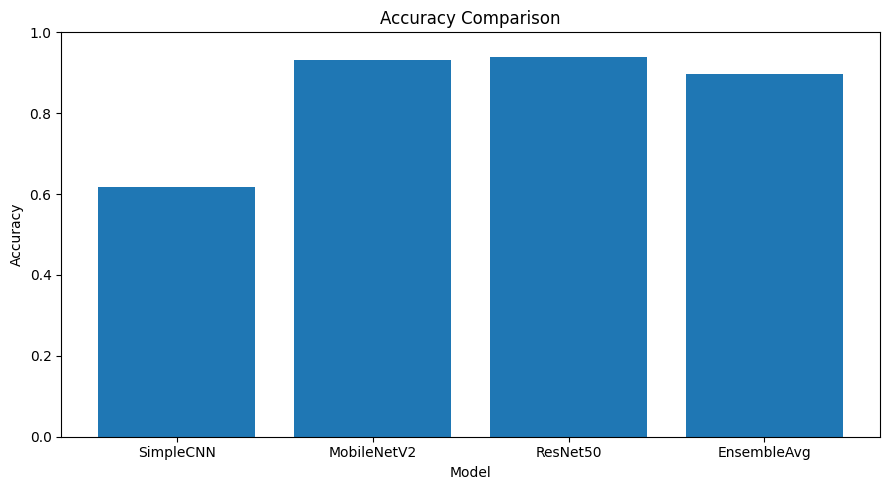

In [3]:
plt.figure(figsize=(9,5))
plt.bar(df["model"], df["accuracy"])
plt.title("Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1.0)
plt.tight_layout()
plt.show()


## 9. Precision Comparison

Precision indicates how accurate the model's positive predictions are.


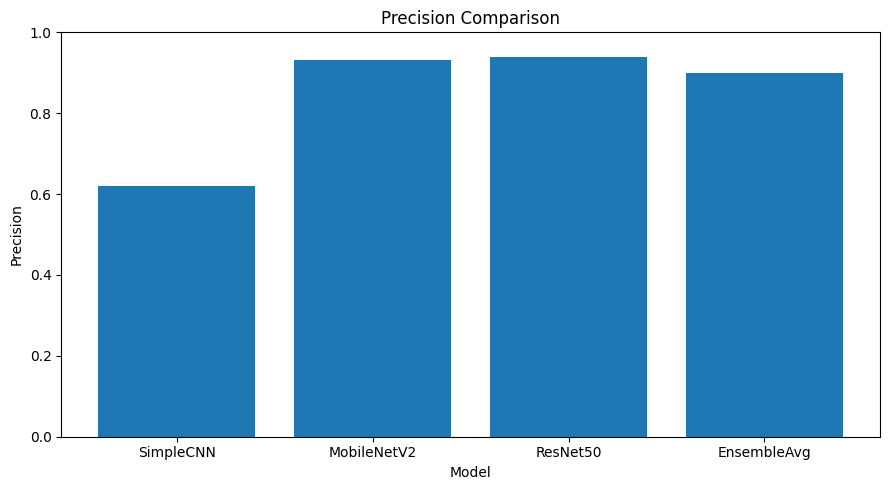

In [4]:
plt.figure(figsize=(9,5))
plt.bar(df["model"], df["precision"])
plt.title("Precision Comparison")
plt.xlabel("Model")
plt.ylabel("Precision")
plt.ylim(0, 1.0)
plt.tight_layout()
plt.show()


## 10. Recall Comparison

Recall indicates how well the model can find the true positive samples.


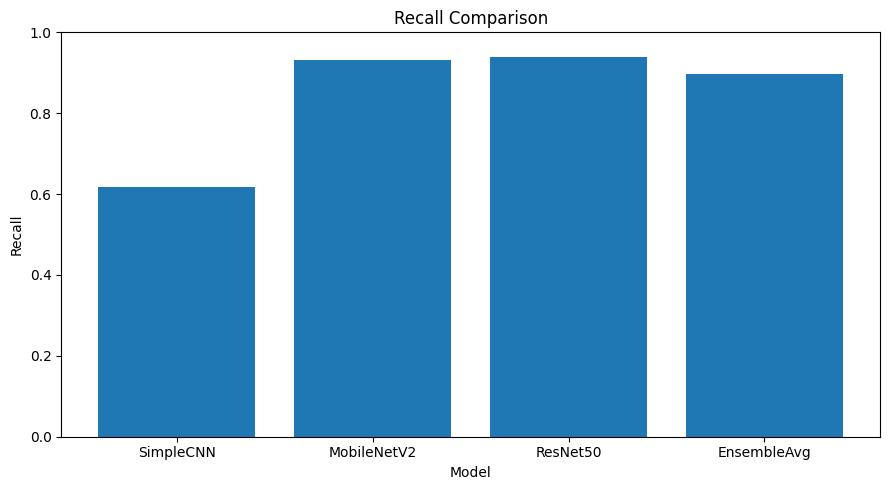

In [5]:
plt.figure(figsize=(9,5))
plt.bar(df["model"], df["recall"])
plt.title("Recall Comparison")
plt.xlabel("Model")
plt.ylabel("Recall")
plt.ylim(0, 1.0)
plt.tight_layout()
plt.show()


## 11. F1-score Comparison

F1-score provides a balance between precision and recall.


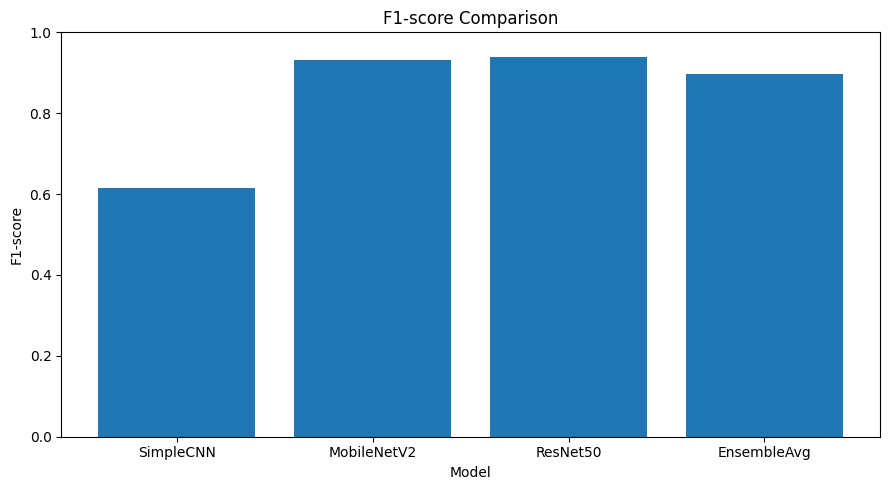

In [6]:
plt.figure(figsize=(9,5))
plt.bar(df["model"], df["f1_score"])
plt.title("F1-score Comparison")
plt.xlabel("Model")
plt.ylabel("F1-score")
plt.ylim(0, 1.0)
plt.tight_layout()
plt.show()


## 12. Training Time Comparison (Single Models Only)

This chart compares the training time of the three individual models.  
The ensemble model is not included because it is a combination step, not a separately trained network.


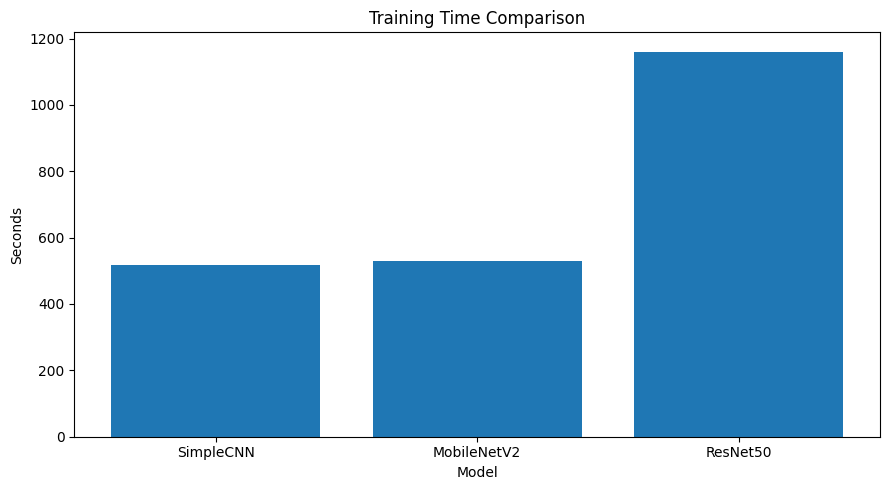

In [7]:
df_single = df[df["model"] != "EnsembleAvg"].copy()

if "train_time_sec" in df_single.columns:
    plt.figure(figsize=(9,5))
    plt.bar(df_single["model"], df_single["train_time_sec"])
    plt.title("Training Time Comparison")
    plt.xlabel("Model")
    plt.ylabel("Seconds")
    plt.tight_layout()
    plt.show()
else:
    print("No training time data found.")


## 13. Best Single Model vs Ensemble

This section directly compares:
- the best individual model
- and the ensemble approach

This helps answer an important research question:

> Does combining multiple models improve the final classification result?


In [8]:
best_single = df[df["model"] != "EnsembleAvg"].sort_values(by="accuracy", ascending=False).iloc[0]

compare_rows = [best_single]
if "EnsembleAvg" in df["model"].values:
    compare_rows.append(df[df["model"] == "EnsembleAvg"].iloc[0])

compare_df = pd.DataFrame(compare_rows)
compare_df


,model,accuracy,precision,recall,f1_score,train_time_sec
2,ResNet50,0.939320,0.939324,0.939320,0.939320,1160.7
3,EnsembleAvg,0.896644,0.899343,0.896644,0.896468,NaN


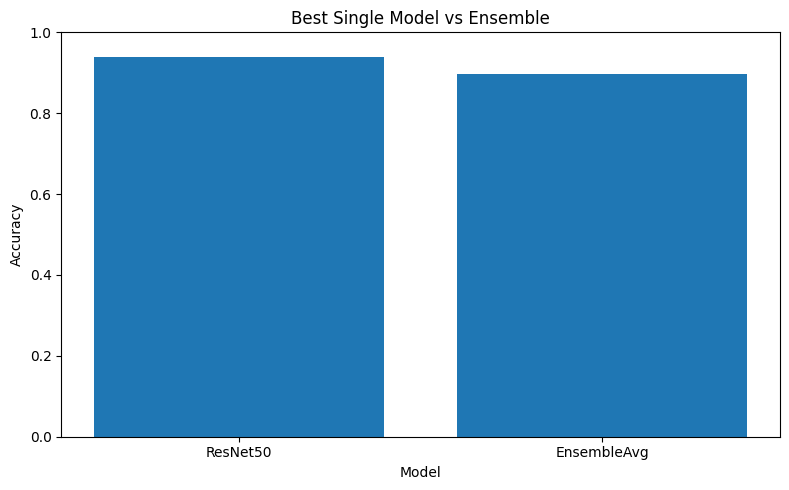

In [9]:
if len(compare_df) == 2:
    plt.figure(figsize=(8,5))
    plt.bar(compare_df["model"], compare_df["accuracy"])
    plt.title("Best Single Model vs Ensemble")
    plt.xlabel("Model")
    plt.ylabel("Accuracy")
    plt.ylim(0, 1.0)
    plt.tight_layout()
    plt.show()
else:
    print("Ensemble result not found. Please run evaluate_ensemble.py first.")


## 14. Final Comparison: Is Ensemble Better?

The next cell automatically checks whether the ensemble method performs better than the best single model.


In [10]:
best_single_acc = float(best_single["accuracy"])

if "EnsembleAvg" in df["model"].values:
    ensemble_acc = float(df[df["model"] == "EnsembleAvg"].iloc[0]["accuracy"])
    diff = ensemble_acc - best_single_acc

    print("Best single model:", best_single["model"])
    print("Best single accuracy:", round(best_single_acc, 4))
    print("Ensemble accuracy:", round(ensemble_acc, 4))
    print("Difference:", round(diff, 4))

    if diff > 0:
        print("Conclusion: Ensemble performs better than the best single model.")
    elif diff < 0:
        print("Conclusion: The best single model still performs better than Ensemble.")
    else:
        print("Conclusion: Both approaches provide the same accuracy.")
else:
    print("Ensemble result not found. Please run evaluate_ensemble.py first.")


Best single model: ResNet50
Best single accuracy: 0.9393
Ensemble accuracy: 0.8966
Difference: -0.0427
Conclusion: The best single model still performs better than Ensemble.


## 15. Formal Discussion

The comparison results should be interpreted as follows:

- If **ResNet50** is the highest-performing single model, it suggests that deeper pretrained architectures can extract visual features more effectively.
- If **MobileNetV2** performs competitively, it may be a better choice for lightweight or faster deployment.
- If **EnsembleAvg** outperforms all single models, it indicates that combining model outputs improves robustness and predictive stability.
- If the ensemble does **not** outperform the best single model, then the best individual model is still the preferred practical choice due to simpler deployment and lower complexity.


## 15. Model Evaluation Insight

The experimental results reveal several important observations:

- **ResNet50** achieved the highest overall performance among the individual models.
- **MobileNetV2** also performed strongly and provided a good trade-off between performance and efficiency.
- **SimpleCNN** achieved the lowest performance, which is expected because it was built from scratch and has a simpler architecture.

### Ensemble Insight
An ensemble method was also evaluated by combining the outputs of the trained models.
Although ensemble learning is often expected to improve performance, in this project it did **not outperform** the best single model.

This suggests that:
- the strongest model already captures most of the useful information,
- the weaker models may not add enough complementary information,
- and ensemble learning is not always guaranteed to improve final accuracy.

Therefore, the most practical conclusion for this project is that **ResNet50 is the best standalone solution** for deployment.


## 16. Deployment and Real-World Usage

The trained models were not only evaluated academically, but also prepared for practical use.

### 16.1 Command-Line Prediction
The file `predict.py` allows the user to provide an image path and obtain a classification result directly from the terminal.

### 16.2 Web Application Deployment
The file `app_gradio.py` launches a simple web interface where users can upload an image and receive an AI prediction instantly.

This deployment step demonstrates that the project is not limited to training and evaluation only.
It extends the solution into a usable AI application, which aligns with the final stage of a standard machine learning lifecycle.


## 17. Conclusion

This notebook presents a formal comparison of deep learning approaches for cat and dog image classification.

The project workflow included:
1. dataset preparation,
2. training three different models,
3. evaluating each model,
4. optionally evaluating an ensemble method,
5. and selecting the most suitable approach for deployment.

The final selected model or method can then be used in a real AI application for classifying new cat and dog images.
